# TAREA 2 SAMUEL ALEJANDRO DURÁN ENRÍQUEZ

In [87]:
import nltk
import os
import re
import setuptools.dist
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

## 2 Bolsas de Palabras, Bigramas y Emociones (40pts)

In [86]:
def get_text_from_file(path_corpus,path_truth):
    tr_txt =[]
    tr_y=[]
    
    with open(path_corpus, "r", encoding='UTF-8') as f_corpus, open(path_truth,"r", encoding='UTF-8') as f_truth:
        for twitt in f_corpus:
            tr_txt+= [twitt]
        for label in f_truth:
            tr_y +=[label]
    
    return tr_txt, tr_y

In [9]:
#print(os.getcwd())
tr_txt, tr_y = get_text_from_file("mex20_train.txt","mex20_train_labels.txt")

Counter({'0\n': 3759, '1\n': 1519})


Text(0.5, 0, 'Class')

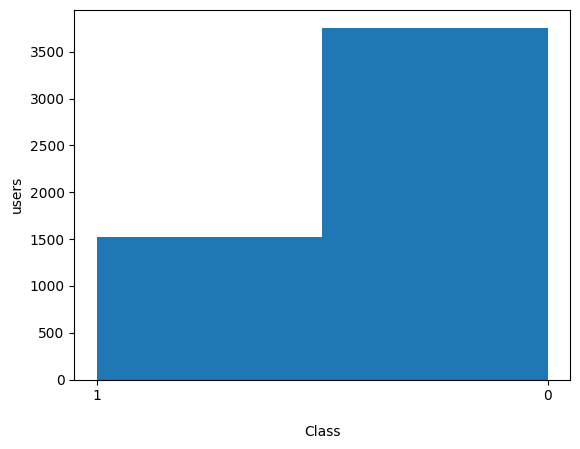

In [10]:
from collections import Counter
import matplotlib.pyplot as plt

print(Counter(tr_y))
plt.hist(tr_y, bins=len(set(tr_y)))

plt.ylabel('users')
plt.xlabel('Class')

In [116]:
#construir vocabulario
from nltk.tokenize import TweetTokenizer
tokenizer = TweetTokenizer()


def indices_diccionario(tr_txt, length=5000):
    #Una lista de lista de palabras
    corpus_palabras =[]
    for doc in tr_txt:
        # Obten las palabras de cada renglón en tr_txt
        corpus_palabras += tokenizer.tokenize(doc)
    fdist= nltk.FreqDist(corpus_palabras)
    #Queremos obtener un ranking con las palabras, para quedarnos con un diccionario 
    #reducido de solo las primeras 5000 palabras 
    #Entonces lo volvemos una lista (que nos da herramientas para manipularlo) lo ordenamos y después lo recortamos
    sort_fdist= list(fdist.items())
    #Con lambda seleccionamos el valor del número para ordenar la lista
    sort_fdist =sorted(sort_fdist, key= lambda x: x[1],reverse=True)
    Vocabulary = sort_fdist[:length]
    print("Lista final", len(Vocabulary))
    #sort_fdist
    #Con la lista hecha lo devolvemos a un diccionario
    #Para hacer la BOW debemos revisar cada elemento para cada documento, esto es mucho más rápido con
    #los diccionarios los llenamos con cada palabra y su ranking de que tan usado es
    dict_indices = dict()
    for rank,(palabra,freq) in enumerate(Vocabulary):
        dict_indices[palabra] = rank
    
    return dict_indices
    
dict_indices= indices_diccionario(tr_txt)

Lista final 5000


## Comienza la construcción de Bolsas de Palabras BoW

In [114]:
#Bolsa de palabras con pesado binario
def BOW_binary(tr_txt,dict_indices):
    BOW=np.zeros((len(tr_txt),len(dict_indices)))
    for contador, tr in enumerate(tr_txt):
        fdist_doc= nltk.FreqDist(tokenizer.tokenize(tr))
        for word in fdist_doc:
            if word in dict_indices:
                BOW[contador,dict_indices[word]]= 1
            #ESTAMOS IGNORANDO LOS VALORES QUE NO ESTÁN EN EL DICCIONARIO
    return BOW

def BOW_freq(tr_txt,dict_indices):
    BOW=np.zeros((len(tr_txt),len(dict_indices)))
    for contador, tr in enumerate(tr_txt):
        fdist_doc= nltk.FreqDist(tokenizer.tokenize(tr))
        for word in fdist_doc:
            if word in dict_indices:
                #un cambio ligero ahora suma cada que encuentra una ocurrencia para hacer freq
                BOW[contador,dict_indices[word]]+= 1
            #ESTAMOS IGNORANDO LOS VALORES QUE NO ESTÁN EN EL DICCIONARIO
    return BOW    

def BOW_tfidf(tr_txt,dict_indices):
    #term frequency inverse document frequency
    #Para idf es necesario contar el total de documentos y el número de veces 
    #que una palabra si aparece en un documento
    BOW=np.zeros((len(tr_txt),len(dict_indices)))
    #una segunda matriz registra si existe o no la palabra
    aux_idf=np.zeros((len(tr_txt),len(dict_indices)))
    for contador, tr in enumerate(tr_txt):
        fdist_doc= nltk.FreqDist(tokenizer.tokenize(tr))
        for word in fdist_doc:
            if word in dict_indices:
                #un cambio ligero ahora suma cada que encuentra una ocurrencia para hacer freq
                BOW[contador,dict_indices[word]]+= 1
                aux_idf[contador,dict_indices[word]]= 1
            #ESTAMOS IGNORANDO LOS VALORES QUE NO ESTÁN EN EL DICCIONARIO

    #Obtenemos el indice idf para
    idf=np.zeros(len(dict_indices))
    for c,i in enumerate(idf):
        if np.sum(aux_idf[:,c]) >0:
            idf[c]=np.log10(len(tr_txt)/np.sum(aux_idf[:,c]))
        else:
            idf[c]=0
        
    #Obtenemos la matriz completa
    BOW = BOW * idf
    
    return BOW        

#Para normalizar dividimos cada elementos en el vector de los documentos entre la norma de ese vector, con lo que lo hacemos
#unitario

#Bolsa de palabras con pesado binario
def BOW_binary_norml2(tr_txt,dict_indices):
    BOW=np.zeros((len(tr_txt),len(dict_indices)))
    for contador, tr in enumerate(tr_txt):
        fdist_doc= nltk.FreqDist(tokenizer.tokenize(tr))
        for word in fdist_doc:
            if word in dict_indices:
                BOW[contador,dict_indices[word]]= 1
            #ESTAMOS IGNORANDO LOS VALORES QUE NO ESTÁN EN EL DICCIONARIO
    #normalización
    for i in range(len(BOW)):
        if np.linalg.norm(BOW[i])>0:
            BOW[i]=BOW[i]/np.linalg.norm(BOW[i])
        
    return BOW

def BOW_freq_norml2(tr_txt,dict_indices):
    BOW=np.zeros((len(tr_txt),len(dict_indices)))
    for contador, tr in enumerate(tr_txt):
        fdist_doc= nltk.FreqDist(tokenizer.tokenize(tr))
        for word in fdist_doc:
            if word in dict_indices:
                #un cambio ligero ahora suma cada que encuentra una ocurrencia para hacer freq
                BOW[contador,dict_indices[word]]+= 1
            #ESTAMOS IGNORANDO LOS VALORES QUE NO ESTÁN EN EL DICCIONARIO
    #normalización        
    for i in range(len(BOW)):
        if np.linalg.norm(BOW[i])>0:
            BOW[i]=BOW[i]/np.linalg.norm(BOW[i])
                
    return BOW    

def BOW_tfidf_norml2(tr_txt,dict_indices):
    #term frequency inverse document frequency
    #Para idf es necesario contar el total de documentos y el número de veces 
    #que una palabra si aparece en un documento
    BOW=np.zeros((len(tr_txt),len(dict_indices)))
    #una segunda matriz registra si existe o no la palabra
    aux_idf=np.zeros((len(tr_txt),len(dict_indices)))
    for contador, tr in enumerate(tr_txt):
        fdist_doc= nltk.FreqDist(tokenizer.tokenize(tr))
        for word in fdist_doc:
            if word in dict_indices:
                #un cambio ligero ahora suma cada que encuentra una ocurrencia para hacer freq
                BOW[contador,dict_indices[word]]+= 1
                aux_idf[contador,dict_indices[word]]= 1
            #ESTAMOS IGNORANDO LOS VALORES QUE NO ESTÁN EN EL DICCIONARIO

    #Obtenemos el indice idf para
    idf=np.zeros(len(dict_indices))
    for c,i in enumerate(idf):
        if np.sum(aux_idf[:,c]) >0:
            idf[c]=np.log10(len(tr_txt)/np.sum(aux_idf[:,c]))
        else:
            idf[c]=0
    #Obtenemos la matriz completa
    BOW = BOW * idf
    #normalización
    for i in range(len(BOW)):
        if np.linalg.norm(BOW[i])>0:
            BOW[i]=BOW[i]/np.linalg.norm(BOW[i])
        
    return BOW  

def BOW_select(i,tr_txt, dict_indices):
    
    if i==0:
        BOW=BOW_binary(tr_txt,dict_indices)
        label="Binario"
    elif i==1:
        BOW=BOW_freq(tr_txt,dict_indices)    
        label="Frecuencia"
    elif i==2:
        BOW=BOW_tfidf(tr_txt,dict_indices)    
        label="TFIDF"
    elif i==3:
        BOW=BOW_binary_norml2(tr_txt,dict_indices)    
        label="Binario norm"
    elif i==4:
        BOW=BOW_freq_norml2(tr_txt,dict_indices)    
        label="Frecuencia norm"
    elif i==5:
        BOW=BOW_tfidf_norml2(tr_txt,dict_indices)    
        label="TFIDF norm"
    else:
        print("contador excedido") 
        exit
    return BOW,label       


## Clasificación con SVM

In [112]:
import sklearn
from sklearn import svm
from sklearn.model_selection import GridSearchCV
from sklearn import metrics
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score,precision_recall_fscore_support

In [78]:
val_txt, val_y = get_text_from_file("mex20_val.txt","mex20_val_labels.txt")

Los puntos 1 al 7 se presentan a continuación:

In [ ]:
# Requerimos sacar las variables para comparar los diferentes 6 modelos
# Dado que no son tan grandes probamos entrenando todas las corridas

parameters = {'C': [0.05, 0.12, 0.25, 0.25, 1.0, 2.0, 4.0]}
# Repetir 6 veces para evaluar cada bolsa e imprimir las estadísticas
svr=svm.LinearSVC(class_weight='balanced')
grid = GridSearchCV(estimator=svr, param_grid=parameters, n_jobs=8, scoring="f1_macro", cv=5)

tr_y = list(map(int, tr_y))
val_y = list(map(int, val_y))

for i in range(6):
    BOW_tr,label = BOW_select(i, tr_txt, dict_indices)
    BOW_val,_ = BOW_select(i,val_txt,dict_indices)
    grid.fit(BOW_tr, tr_y)
    y_pred= grid.predict(BOW_val)
    
    #p,r,f,_ = precision_recall_fscore_support(val_y,y_pred,average='macro', pos_label=1)
    
    print("Resultados para", f"{label}")
    print("Matriz de confusión" )
    print(confusion_matrix(val_y,y_pred))
    print(metrics.classification_report(val_y,y_pred))
    
    

Resultados para Binario
Matriz de confusión
[[357  61]
 [ 49 120]]
              precision    recall  f1-score   support

           0       0.88      0.85      0.87       418
           1       0.66      0.71      0.69       169

    accuracy                           0.81       587
   macro avg       0.77      0.78      0.78       587
weighted avg       0.82      0.81      0.81       587

Resultados para Frecuencia
Matriz de confusión
[[357  61]
 [ 49 120]]
              precision    recall  f1-score   support

           0       0.88      0.85      0.87       418
           1       0.66      0.71      0.69       169

    accuracy                           0.81       587
   macro avg       0.77      0.78      0.78       587
weighted avg       0.82      0.81      0.81       587

Resultados para TFIDF
Matriz de confusión
[[363  55]
 [ 63 106]]
              precision    recall  f1-score   support

           0       0.85      0.87      0.86       418
           1       0.66      0.63  

| Métrica               | Binario | Frecuencia | TFIDF | Binario norm | Frecuencia norm | TFIDF norm |
|-----------------------|---------|------------|-------|--------------|-----------------|------------|
| **Precision (0)**      | 0.88    | 0.88       | 0.85  | 0.89         | 0.89            | 0.89       |
| **Recall (0)**         | 0.85    | 0.85       | 0.87  | 0.85         | 0.85            | 0.85       |
| **F1-score (0)**       | 0.87    | 0.87       | 0.86  | 0.87         | 0.87            | 0.87       |
| **Precision (1)**      | 0.66    | 0.66       | 0.66  | 0.67         | 0.67            | 0.67       |
| **Recall (1)**         | 0.71    | 0.71       | 0.63  | 0.73         | 0.73            | 0.74       |
| **F1-score (1)**       | 0.69    | 0.69       | 0.64  | 0.70         | 0.70            | 0.70       |
| **Accuracy**           | 0.81    | 0.81       | 0.80  | 0.82         | 0.82            | 0.82       |
| **Macro avg Precision**| 0.77    | 0.77       | 0.76  | 0.78         | 0.78            | 0.78       |
| **Macro avg Recall**   | 0.78    | 0.78       | 0.75  | 0.79         | 0.79            | 0.80       |
| **Macro avg F1-score** | 0.78    | 0.78       | 0.75  | 0.78         | 0.78            | 0.79       |
| **Weighted avg Precision**| 0.82 | 0.82       | 0.80  | 0.82         | 0.82            | 0.83       |
| **Weighted avg Recall**| 0.81    | 0.81       | 0.80  | 0.82         | 0.82            | 0.82       |
| **Weighted avg F1-score**| 0.81  | 0.81       | 0.80  | 0.82         | 0.82            | 0.82       |


El mejor clasificador por poco es el TFIDF normalizado. En general los normalizados si funcionaron mejor que los no normalizados.
El TFIDF:
- Tuvo la mejor precisión (más verdadero como verdadero y pocos falsos positivos)
- Tuvo un recall comparable o mejor al de otras clases
- Tuvo el mejor accuracy (más en la categoría correspondiente)

Esto tambien en las categorias pesadas.

8. De las configuraciones anteriores elija la mejor y evalúela con más y menos términos
(e.g., 1000 y 7000). Ponga una tabla dónde compare tres configuraciones distintas.

In [ ]:
#Variable sigue teniendo todo el vocabulario
puntos=[1000,5000,7000]

#Volvemos a evaluar el modelo para SVC
parameters = {'C': [0.05, 0.12, 0.25, 0.25, 1.0, 2.0, 4.0]}
svr=svm.LinearSVC(class_weight='balanced')
grid = GridSearchCV(estimator=svr, param_grid=parameters, n_jobs=8, scoring="f1_macro", cv=5)
tr_y = list(map(int, tr_y))
val_y = list(map(int, val_y))

for terminos in puntos:
    dict_indices_conf= indices_diccionario(tr_txt,length=terminos)
    #seleccionar solamente TFIDF normalizado que fue el mejor
    BOW_tr,label = BOW_select(5, tr_txt, dict_indices_conf)
    BOW_val,_ = BOW_select(5,val_txt,dict_indices_conf)
    grid.fit(BOW_tr, tr_y)
    y_pred= grid.predict(BOW_val)
    
    #p,r,f,_ = precision_recall_fscore_support(val_y,y_pred,average='macro', pos_label=1)
    
    print("Resultados para", f"{label}", f"{terminos}", "terminos en diccionario")
    print("Matriz de confusión" )
    print(confusion_matrix(val_y,y_pred))
    print(metrics.classification_report(val_y,y_pred))

Resultados para TFIDF norm 1000 terminos en diccionario
Matriz de confusión
[[350  68]
 [ 41 128]]
              precision    recall  f1-score   support

           0       0.90      0.84      0.87       418
           1       0.65      0.76      0.70       169

    accuracy                           0.81       587
   macro avg       0.77      0.80      0.78       587
weighted avg       0.83      0.81      0.82       587

Resultados para TFIDF norm 5000 terminos en diccionario
Matriz de confusión
[[357  61]
 [ 44 125]]
              precision    recall  f1-score   support

           0       0.89      0.85      0.87       418
           1       0.67      0.74      0.70       169

    accuracy                           0.82       587
   macro avg       0.78      0.80      0.79       587
weighted avg       0.83      0.82      0.82       587

Resultados para TFIDF norm 7000 terminos en diccionario
Matriz de confusión
[[356  62]
 [ 43 126]]
              precision    recall  f1-score   sup

| Métrica                | 1000 términos | 5000 términos | 7000 términos |
|------------------------|--------------|--------------|--------------|
| Precisión (Clase 0)   | 0.90         | 0.89         | 0.89         |
| Recall (Clase 0)      | 0.84         | 0.85         | 0.85         |
| F1-Score (Clase 0)    | 0.87         | 0.87         | 0.87         |
| Precisión (Clase 1)   | 0.65         | 0.67         | 0.67         |
| Recall (Clase 1)      | 0.76         | 0.74         | 0.75         |
| F1-Score (Clase 1)    | 0.70         | 0.70         | 0.71         |
| Accuracy              | 0.81         | 0.82         | 0.82         |


Existe una ligera mejora pasando de 1000 términos a 5000. Aunque baja la precisión para la clase 0 y el recall para la clase 1, para el resto de metricas se mantiene igual o mejora. Para los 7000 términos la mejora es mucho menos, no aprece tener tanto impacto agregar más términos, es probable que se esten agregando palabras muy poco usadas ya.

9. Utilice el recurso léxico del Consejo Nacional de Investigación de Canadá llamado
"EmoLex" (https://www.saifmohammad.com/WebPages/NRC-Emotion-Lexicon.htm) para
construir una "Bolsa de Emociones" de los Tweets de agresividad (Debe usar EmoLex en
Español). Para esto, una estrategia sencilla sería enmascarar (sustituir) cada palabra con
su emoción, y después construir la Bolsa de Emociones (BoE).

In [ ]:
#Si en lugar de la palabra mencionamos su emoción esto podría ayudar a que
#la frecuencia de palabras negativas aumente y mejorar el clasificador.
#Obtenemos entonces primero la bolsa de emociones en español
import numpy as np
#Abriremos el txt con pandas y manipularemos la tabla para solo tener la palabra en español y su emoción directamente.
with open("Spanish-NRC-EmoLex.txt", "r", encoding="utf-8") as file:
    lexicon = [line.strip().split("\t") for line in file]

# Mostrar los primeros datos
#for row in lexicon[:5]:
#    print(row)

['English Word', 'anger', 'anticipation', 'disgust', 'fear', 'joy', 'negative', 'positive', 'sadness', 'surprise', 'trust', 'Spanish Word']
['aback', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', 'detrás']
['abacus', '0', '0', '0', '0', '0', '0', '0', '0', '0', '1', 'ábaco']
['abandon', '0', '0', '0', '1', '0', '1', '0', '1', '0', '0', 'abandonar']
['abandoned', '1', '0', '0', '1', '0', '1', '0', '1', '0', '0', 'abandonado']


In [ ]:
lexicon_esp_dict = {}

emociones = lexicon[0][1:11]  # Suponiendo que la columna 0 tiene palabras y las emociones están en 1-10

for renglon in lexicon[1:]:  # Evitamos el encabezado
    palabra = renglon[11]  # Obtenemos la palabra de la última columna
    valores = np.char.multiply(emociones, np.array(renglon[1:11], dtype=int))  # Multiplica emociones por valores
    emociones_filtradas = [em for em in valores if em]  # Filtrar solo emociones activas "" es false
    lexicon_esp_dict[palabra] = ",".join(emociones_filtradas)  # Convertir a string separado por comas

#Con el diccionario ya podemos buscar eficientemente cuando queramos sustituir
print(lexicon_esp_dict)


{'detrás': '', 'ábaco': 'trust', 'abandonar': 'negative', 'abandonado': 'anger, negative, sadness', 'abandono': 'anger, fear, negative, sadness, surprise', 'disminuir': '', 'disminución': '', 'abba': 'positive', 'abad': 'trust', 'abreviar': '', 'abreviatura': '', 'abdomen': '', 'abdominal': '', 'secuestro': 'negative, sadness', 'aberrante': 'negative', 'aberración': 'disgust, negative', 'suspensión': 'fear, negative', 'aborrecer': 'anger, disgust, fear, negative', 'aborrecible': 'anger, disgust, fear, negative', 'cumplir': '', 'capacidad': '', 'abyecto': 'disgust, negative', 'ablación': '', 'ardiendo': '', 'anormal': 'disgust, negative', 'a bordo': '', 'morada': '', 'abolir': 'anger, negative', 'abolición': 'negative', 'abominable': 'disgust, fear, negative', 'abominación': 'anger, disgust, fear, negative', 'aborigen': '', 'abortar': 'negative', 'aborto': 'disgust, fear, negative, sadness', 'abortivo': 'negative, sadness', 'abundar': '', 'anteriormente mencionado': 'positive', 'abrasió

In [110]:
tr_txt, tr_y = get_text_from_file("mex20_train.txt","mex20_train_labels.txt")
val_txt, val_y = get_text_from_file("mex20_val.txt","mex20_val_labels.txt")

tr_txt[0:10]

['@USUARIO @USUARIO @USUARIO Q se puede esperar del maricon de closet de la Yañez aun recuerdo esa ves q lo vi en zona rosa viendo quien lo levantada\n',
 '@USUARIO La piel nueva siempre arde un poquito los primeros días... y más con este puto clima\n',
 'Ustedes no se enamoran de mí… por tontas.\n',
 'Me las va a pagar esa puta gorda roba tuits...\n',
 '@USUARIO LA GENTE ES TONTA PORQUE NO SE DAN CUENTA QUE TÚ HACES A BATMAN AZUL\n',
 'Estoy muy encabronada con las pseudo feministas por tontas e iletradas, a veces me avergüenza ser mujer; preferiría tener un falo. #NiUnaMas\n',
 'Anden putos, recuerdan el #noerapenal #Holanda fuera de #Rusia2018, esto se llama #karma ehhhhhhhh #puuuuuutos\n',
 'Si no tienen chichis no traten de enseñar se ven muy mal y más cuando son prietas.\n',
 'Ojalá asi me agarrars cuando te digo que me voy en lugar de correrme a la verga cada 5 minutos.\n',
 '@USUARIO @USUARIO @USUARIO @USUARIO Es solo un HDP aprovechado y que su "Diosito Bimbo" me perdone\n']

In [ ]:
import spacy
import es_core_news_sm

#Buscamos ahora cambiar cada renglón por su emoción base pero 
#primero tenemos que lematizar, cambiar las palabras a su forma base
#en Train y Val. Nos aprovecharemos de Spacy como dice el comentario

nlp = es_core_news_sm.load()

# Función para lematizar el texto
def lematizar(textos):
    lemas = []
    for texto in textos:
        doc = nlp(texto)
        lemas_texto = [token.lemma_ for token in doc]
        lemas.append(" ".join(lemas_texto))
    return lemas

# Procesar el texto con spaCy
lemma_tr_txt = lematizar(tr_txt)
lemma_val_txt = lematizar(val_txt)


In [109]:
#Como se observa la lematización no es perfecta, pero si cambia muchos verbos a su forma base
lemma_tr_txt[0:10]

['@usuario @usuario @usuario Q él poder anticipation , joy , positive , surprise , trust del maricon de closet de el Yañez aun ese ves q él ver en  rós ver quien él levantado',
 '@usuario el siempre arder uno poquito el primero  ... y más con este puto climar',
 'tú anticipation él enamorar de yo … por tonta .',
 'yo él ir a anger , anticipation , joy , positive , trust ese disgust, negative gordo roba tuits ...',
 '@usuario el ser tonta PORQUE anticipation él DAN  QUE TÚ HACES A BATMAN AZUL',
 'estar encabronado con el pseudo feminista por tonta e iletrada , a veces yo avergüenzar ser mujer ; positive, trust tener uno falo . # NiUnaMas',
 'andir puto , el # noerapenal # Holanda fuera de # Rusia 2018 , este él #  ehhhhhhhh # puuuuuuto',
 'si anticipation tener chichis anticipation anger , anticipation , disgust , fear , joy , negative , positive , sadness , surprise , trust de joy , positive , surprise , trust él ver negative y más negative ser prieto .',
 'ojalá asi yo agarrars negati

In [153]:
#Vamos a manipular strings para sustituir la palabra
#construir vocabulario y diccionario con nuevas palabras 
from nltk.tokenize import TweetTokenizer

tokenizer = TweetTokenizer()

def enmascarado(lemma_texto,diccionario_emociones):
    #El texto se alimenta como lista de strings.
    lemma_textos=np.copy(lemma_texto)
    for contador, tr in enumerate(lemma_texto):
        #tokenizamos para tener las palabras
        renglon_token=tokenizer.tokenize(tr)
        for word in renglon_token:
            #para cada palabra en cada renglón verificamos si está
            #En el diccionario y si está en la oración.
            if word in diccionario_emociones:
                 # Tomamos la oración original y la tokenizamos
                aux = tokenizer.tokenize(lemma_texto[contador])
                # Reemplazamos la palabra por su versión en diccionario_emociones
                if word in aux:  
                    aux[aux.index(word)] = diccionario_emociones[word]
                
                # Unimos los tokens correctamente con espacios
                #para el texto reemplazado
                lemma_textos[contador] = " ".join(aux)  
                
    return lemma_textos.tolist()
tr_emocion= enmascarado(lemma_tr_txt, lexicon_esp_dict)
val_emocion=enmascarado(val_txt, lexicon_esp_dict)

#Ahora muchos textos son poco reconocibles, aunque las emociones esten en ingles nos sirven para clasificar
tr_emocion[0:10]

['@usuario @usuario @usuario Q él poder anticipation , joy , positive , surprise , trust del maricon de closet de el Yañez aun ese ves q él ver en  rós ver quien él levantado',
 '@usuario el siempre arder uno poquito el primero  ... y más con este puto climar',
 'tú anticipation él enamorar de yo … por tonta .',
 'yo él ir a anger , anticipation , joy , positive , trust ese disgust, negative gordo roba tuits ...',
 '@usuario el ser tonta PORQUE anticipation él DAN  QUE TÚ HACES A BATMAN AZUL',
 'estar encabronado con el pseudo feminista por tonta e iletrada , a veces yo avergüenzar ser mujer ; positive, trust tener uno falo . # NiUnaMas',
 'andir puto , el # noerapenal # Holanda fuera de # Rusia 2018 , este él #  ehhhhhhhh # puuuuuuto',
 'si anticipation tener chichis anticipation anger , anticipation , disgust , fear , joy , negative , positive , sadness , surprise , trust de joy , positive , surprise , trust él ver negative y más negative ser prieto .',
 'ojalá asi yo agarrars negati

In [117]:
#Una lista de lista de palabras
emociones_dict_indices= indices_diccionario(tr_emocion)

Lista final 5000


10. Usa tú BoE de alguna forma y clasifica con SVM. Ponga una tabla comparativa a modo
de resumen con tres pesados (bin, tf, tfidf), normalize cada uno si lo cree conveniente.


In [ ]:
#Ya tenemos un diccionario de indices, un vocabulario y los corpus, entonces pasemos a evaluar las BoW.
# Requerimos sacar las variables para comparar los diferentes 6 modelos
# Dado que no son tan grandes probamos entrenando todas las corridas

parameters = {'C': [0.05, 0.12, 0.25, 0.25, 1.0, 2.0, 4.0]}
# Repetir 3 veces para evaluar cada bolsa e imprimir las estadísticas
svr=svm.LinearSVC(class_weight='balanced')
grid = GridSearchCV(estimator=svr, param_grid=parameters, n_jobs=8, scoring="f1_macro", cv=5)

#Sacamos las etiquetas como numero y a lista
tr_y = list(map(int, tr_y))
val_y = list(map(int, val_y))

#Probar solo las versiones normalizadas
for i in range(3,6):
    BOW_tr,label = BOW_select(i, tr_emocion, emociones_dict_indices)
    BOW_val,_ = BOW_select(i,val_emocion,emociones_dict_indices)
    grid.fit(BOW_tr, tr_y)
    y_pred= grid.predict(BOW_val)
    
    #p,r,f,_ = precision_recall_fscore_support(val_y,y_pred,average='macro', pos_label=1)
    
    print("Resultados para", f"{label}")
    print("Matriz de confusión" )
    print(confusion_matrix(val_y,y_pred))
    print(metrics.classification_report(val_y,y_pred))
        

Resultados para Binario norm
Matriz de confusión
[[332  86]
 [ 53 116]]
              precision    recall  f1-score   support

           0       0.86      0.79      0.83       418
           1       0.57      0.69      0.63       169

    accuracy                           0.76       587
   macro avg       0.72      0.74      0.73       587
weighted avg       0.78      0.76      0.77       587

Resultados para Frecuencia norm
Matriz de confusión
[[332  86]
 [ 53 116]]
              precision    recall  f1-score   support

           0       0.86      0.79      0.83       418
           1       0.57      0.69      0.63       169

    accuracy                           0.76       587
   macro avg       0.72      0.74      0.73       587
weighted avg       0.78      0.76      0.77       587

Resultados para TFIDF norm
Matriz de confusión
[[331  87]
 [ 47 122]]
              precision    recall  f1-score   support

           0       0.88      0.79      0.83       418
           1       0

| Métrica       | Binario norm | Frecuencia norm | TFIDF norm |
|--------------|-------------|----------------|------------|
| Precisión (0) | 0.86        | 0.86           | 0.88       |
| Precisión (1) | 0.57        | 0.57           | 0.58       |
| Recall (0)    | 0.79        | 0.79           | 0.79       |
| Recall (1)    | 0.69        | 0.69           | 0.72       |
| F1-Score (0)  | 0.83        | 0.83           | 0.83       |
| F1-Score (1)  | 0.63        | 0.63           | 0.65       |
| Accuracy      | 0.76        | 0.76           | 0.77       |



La bolsa de emociones no presenta un desempeño mejor que la bolsa de palabras normal. De hecho empeoran en general las métricas para la clase 1. Esto puede deberse las multiples etiquetas que se asignaron por cada palabra cambiada. En el ejemplo del texto con emociones por ejemplo se puede ver que cambio la primera oración:

@USUARIO @USUARIO @USUARIO Q se puede esperar del maricon de closet de la Yañez aun recuerdo esa ves q lo vi en zona rosa viendo quien lo levantada\n',

@usuario @usuario @usuario Q él poder anticipation , joy , positive , surprise , trust del maricon de closet de el Yañez aun ese ves q él ver en  rós ver quien él levantado'.

Gracias a la palabra esperar termino pareciendo una oración positiva, aunque su etiqueta es 1. Cosas como esta pudieron alterar la eficiencia de predecir textos negativos, al confundir con el lenguaje de los positivos.



## 3 Recurso Línguistico de Emociones Mexicano (30 pts)


1. Utilice el recurso léxico llamado "Spanish Emotion Lexicon (SEL)" del Dr. Grigori Sidorov,
profesor del Centro de Investigación en Computación (CIC) del Instituto Politécnico
Nacional (http://www.cic.ipn.mx/∼sidorov/), para enmascarar cada palabra con su emoción, y después construir la Bolsa de Emociones con algún pesado (e.g., binario, tf, tfidf).
Proponga alguna estrategia para incorporar el "valor" del "Probability Factor of Affective
use" en su representación vectorial del documento. Evalúa y escribe una tabla comparativa a modo de resumen con al menos tres pesados: binario, frecuencia, tfidf. Normalize
cada pesado según lo crea conveniente.

Sobre SEL: 
SEL contains 2,036 words that are associated with the measure of Probability Factor of Affective use (PFA) with respect to at least one basic emotion: joy, anger, fear, sadness, surprise, and disgust. 

Tiene entonces una sola emoción relacionada con la palabra y una probabilidad de que tanto se usa en ese caso.



In [134]:
#Obtengamos el diccionario con SEL
#latin 1 nuevo encoder utf-8 no funciona
with open("SEL.txt", "r", encoding="latin-1") as file:
    SEL = [line.strip().split("\t") for line in file]

#Hacemos dos diccionarios, uno para PFA y otro para emoción.
dicc_PFA = {}
dicc_emocion = {}

# Iterar sobre la lista, omitiendo el encabezado
for fila in SEL[1:]:
    llave, valor1, valor2 = fila
    dicc_PFA[llave] = valor1
    dicc_emocion[llave] = valor2

Queremos hacer una bolsa de emociones y considerar el pesado de las palabras. Debería ayudarnos a decidir. Es decir, hacer más diferente las frases que tengan palabras con alto PFA y bajo PFA. Nos basamos en la mejor BoW de esta tarea tfidf. 

El valor asignado a la palabra se multiplica por 
$$ (1+ \frac{PFA}{1+PFA}) $$

De manera que si las probabilidades son 0 entonces permanece igual, pero si se repite varias veces y tiene un valor alto, ese índice crecerá también, hasta un máximo de 2.

In [154]:
lemma_tr_txt = lematizar(tr_txt)
lemma_val_txt = lematizar(val_txt)

tr_SEL= enmascarado(lemma_tr_txt, dicc_emocion)
val_SEL= enmascarado(val_txt, dicc_emocion)

SEL_dict_indices= indices_diccionario(tr_SEL)


Lista final 5000


In [155]:
lemma_tr_txt[:10]

['@usuario @usuario @usuario Q él poder esperar del maricon de closet de el Yañez aun recordar ese ves q él ver en zona rós ver quien él levantado \n',
 '@usuario el piel nuevo siempre arder uno poquito el primero día ... y más con este puto climar \n',
 'tú no él enamorar de yo … por tonta . \n',
 'yo él ir a pagar ese puta gordo roba tuits ... \n',
 '@usuario  el gente ser tonta PORQUE no él DAN cuenta QUE TÚ HACES A BATMAN AZUL \n',
 'estar mucho encabronado con el pseudo feminista por tonta e iletrada , a veces yo avergüenzar ser mujer ; preferir tener uno falo . # NiUnaMas \n',
 'andir puto , recordar el # noerapenal # Holanda fuera de # Rusia2018 , este él llamar # karma ehhhhhhhh # puuuuuuto \n',
 'si no tener chichis no tratar de enseñar él ver mucho mal y más cuando ser prieto . \n',
 'ojalá asi yo agarrars cuando tú decir que yo ir en lugar de correr yo a el verga cada 5 minuto . \n',
 '@usuario @usuario @USUARIO @USUARIO ser solo uno HDP aprovechado y que su " Diosito Bimbo 

In [156]:
tr_SEL[:10]

['@usuario @usuario @usuario Q él poder esperar del maricon de closet de el Yañez aun recordar ese ves q él ver en zona rós ver quien él levantado \n',
 '@usuario el piel nuevo siempre arder uno poquito el primero día ... y más con este puto climar \n',
 'tú no él Alegría de yo … por tonta .',
 'yo él ir a pagar ese puta gordo roba tuits ... \n',
 '@usuario el gente ser tonta PORQUE no él DAN Enojo QUE TÚ HACES A BATMAN AZUL',
 'estar mucho encabronado con el pseudo feminista por tonta e iletrada , a veces yo avergüenzar ser mujer ; preferir tener uno falo . # NiUnaMas \n',
 'andir puto , recordar el # noerapenal # Holanda fuera de # Rusia2018 , este él llamar # karma ehhhhhhhh # puuuuuuto \n',
 'si no tener chichis no tratar de enseñar él ver mucho Tristeza y más cuando ser prieto .',
 'ojalá asi yo agarrars cuando tú decir que yo ir en lugar de correr yo a el verga cada 5 minuto . \n',
 '@usuario @usuario @USUARIO @USUARIO ser Tristeza uno HDP aprovechado y que su " Diosito Bimbo " y

In [189]:
def BOW_tfidf_norml2_PFA(lemma_text,SEL_text,dicc_PFA,dicc_emocion,dict_indices):
    
    BOW=np.zeros((len(SEL_text),len(dict_indices)))
    #una segunda matriz registra si existe o no la palabra
    aux_idf=np.zeros((len(SEL_text),len(dict_indices)))
    aux_PFA=np.zeros((len(SEL_text),len(dict_indices)))
    
    #Matriz auxiliar para llenarla con probabilidades sumadas de la palabra
    for contador, tr in enumerate(lemma_text):
        renglon= tokenizer.tokenize(tr)
        for word in renglon:
            if word in dicc_emocion:
                if dicc_emocion[word] in dict_indices:
                    aux_PFA[contador, dict_indices[dicc_emocion[word]]]+= float(dicc_PFA[word])
                    
    #Construimos bolsa normal                
    for contador, tr in enumerate(SEL_text):
        fdist_doc= nltk.FreqDist(tokenizer.tokenize(tr))
        for word in fdist_doc:
            if word in dict_indices:
                #un cambio ligero ahora suma cada que encuentra una ocurrencia para hacer freq
                BOW[contador,dict_indices[word]]+= 1
                aux_idf[contador,dict_indices[word]]= 1
            #ESTAMOS IGNORANDO LOS VALORES QUE NO ESTÁN EN EL DICCIONARIO

    #Obtenemos el indice idf para
    idf=np.zeros(len(dict_indices))
    for c,i in enumerate(idf):
        if np.sum(aux_idf[:,c]) >0:
            idf[c]=np.log10(len(SEL_text)/np.sum(aux_idf[:,c]))
        else:
            idf[c]=0
            
    #Obtenemos la matriz completa
    
    BOW = BOW * idf
    
    #Calculamos valores para PFA
    aux_PFA = 1 + aux_PFA/(1+aux_PFA)
    BOW= BOW*aux_PFA
    #normalización
    
    for i in range(len(BOW)):
        if np.linalg.norm(BOW[i])>0:
            BOW[i]=BOW[i]/np.linalg.norm(BOW[i])
        
    return BOW  

Evaluamos la BOW con PFA.

In [190]:
parameters = {'C': [0.05, 0.12, 0.25, 0.25, 1.0, 2.0, 4.0]}
# Repetir 3 veces para evaluar cada bolsa e imprimir las estadísticas
svr=svm.LinearSVC(class_weight='balanced')
grid = GridSearchCV(estimator=svr, param_grid=parameters, n_jobs=8, scoring="f1_macro", cv=5)

#Sacamos las etiquetas como numero y a lista
tr_y = list(map(int, tr_y))
val_y = list(map(int, val_y))

#Probar solo las versiones normalizadas
BOW_tr=BOW_tfidf_norml2_PFA(lemma_tr_txt,tr_SEL,dicc_PFA,dicc_emocion,SEL_dict_indices)
BOW_val = BOW_tfidf_norml2_PFA(lemma_val_txt,val_SEL,dicc_PFA,dicc_emocion,SEL_dict_indices)
grid.fit(BOW_tr, tr_y)
y_pred= grid.predict(BOW_val)
    
#p,r,f,_ = precision_recall_fscore_support(val_y,y_pred,average='macro', pos_label=1)
    
print("Resultados para", "TFIDF norm con PFA")
print("Matriz de confusión" )
print(confusion_matrix(val_y,y_pred))
print(metrics.classification_report(val_y,y_pred))

Resultados para TFIDF norm con PFA
Matriz de confusión
[[313 105]
 [ 41 128]]
              precision    recall  f1-score   support

           0       0.88      0.75      0.81       418
           1       0.55      0.76      0.64       169

    accuracy                           0.75       587
   macro avg       0.72      0.75      0.72       587
weighted avg       0.79      0.75      0.76       587



Comparamos contra las BOW con SEL de binario, tf, y tfidf

In [191]:
parameters = {'C': [0.05, 0.12, 0.25, 0.25, 1.0, 2.0, 4.0]}
# Repetir 3 veces para evaluar cada bolsa e imprimir las estadísticas
svr=svm.LinearSVC(class_weight='balanced')
grid = GridSearchCV(estimator=svr, param_grid=parameters, n_jobs=8, scoring="f1_macro", cv=5)

#Sacamos las etiquetas como numero y a lista
tr_y = list(map(int, tr_y))
val_y = list(map(int, val_y))

#Probar solo las versiones normalizadas
for i in range(3,6):
    BOW_tr,label = BOW_select(i, tr_SEL, SEL_dict_indices)
    BOW_val,_ = BOW_select(i,val_SEL, SEL_dict_indices)
    grid.fit(BOW_tr, tr_y)
    y_pred= grid.predict(BOW_val)
    
    #p,r,f,_ = precision_recall_fscore_support(val_y,y_pred,average='macro', pos_label=1)
    
    print("Resultados para", f"{label}")
    print("Matriz de confusión" )
    print(confusion_matrix(val_y,y_pred))
    print(metrics.classification_report(val_y,y_pred))
        

Resultados para Binario norm
Matriz de confusión
[[312 106]
 [ 42 127]]
              precision    recall  f1-score   support

           0       0.88      0.75      0.81       418
           1       0.55      0.75      0.63       169

    accuracy                           0.75       587
   macro avg       0.71      0.75      0.72       587
weighted avg       0.78      0.75      0.76       587

Resultados para Frecuencia norm
Matriz de confusión
[[312 106]
 [ 42 127]]
              precision    recall  f1-score   support

           0       0.88      0.75      0.81       418
           1       0.55      0.75      0.63       169

    accuracy                           0.75       587
   macro avg       0.71      0.75      0.72       587
weighted avg       0.78      0.75      0.76       587

Resultados para TFIDF norm
Matriz de confusión
[[317 101]
 [ 43 126]]
              precision    recall  f1-score   support

           0       0.88      0.76      0.81       418
           1       0

| Métrica         | TFIDF norm con PFA | Binario norm | Frecuencia norm | TFIDF norm |
|----------------|-------------------|--------------|----------------|-------------|
| **Categoría 0** |                   |              |                |             |
| Precision      | 0.88               | 0.88         | 0.88           | 0.88        |
| Recall        | 0.75               | 0.75         | 0.75           | 0.76        |
| F1-score      | 0.81               | 0.81         | 0.81           | 0.81        |
| **Categoría 1** |                   |              |                |             |
| Precision      | 0.55               | 0.55         | 0.55           | 0.56        |
| Recall        | 0.76               | 0.75         | 0.75           | 0.75        |
| F1-score      | 0.64               | 0.63         | 0.63           | 0.64        |
| **General**    |                   |              |                |             |
| Accuracy      | 0.75               | 0.75         | 0.75           | 0.75        |


Las metricas de utilizar PFA aumentaron en comparación contra el resto de algoritmos que no usaron PFA. Aunque el aumento fue a causa de la clasificación correcta de un dato más. Estos valores siguen sin ser mejores que la clasificación sin utilizar emociones. 

## 4 ¿Podemos mejorar con Bigramas? (30 pts)


1. Hacer un experimento dónde concatene una buena BoW según sus experimentos anteriores con otra BoW construida a partir de los 1000 bigramas más frecuentes.


In [200]:
#La mejor BoW fue TFIDF sin bolsa de emociones, agregaremos 
# entonces una bolsa de emociones con bigramas. 
from nltk.tokenize import TweetTokenizer
from nltk.util import bigrams
tokenizer = TweetTokenizer()

token = tokenizer.tokenize(tr_txt[0])
bigram =list(bigrams(token))
bigram
nltk.FreqDist(bigram).items()



dict_items([(('@USUARIO', '@USUARIO'), 2), (('@USUARIO', 'Q'), 1), (('Q', 'se'), 1), (('se', 'puede'), 1), (('puede', 'esperar'), 1), (('esperar', 'del'), 1), (('del', 'maricon'), 1), (('maricon', 'de'), 1), (('de', 'closet'), 1), (('closet', 'de'), 1), (('de', 'la'), 1), (('la', 'Yañez'), 1), (('Yañez', 'aun'), 1), (('aun', 'recuerdo'), 1), (('recuerdo', 'esa'), 1), (('esa', 'ves'), 1), (('ves', 'q'), 1), (('q', 'lo'), 1), (('lo', 'vi'), 1), (('vi', 'en'), 1), (('en', 'zona'), 1), (('zona', 'rosa'), 1), (('rosa', 'viendo'), 1), (('viendo', 'quien'), 1), (('quien', 'lo'), 1), (('lo', 'levantada'), 1)])

In [202]:
#La mejor BoW fue TFIDF sin bolsa de emociones, agregaremos 
# entonces una bolsa de emociones con bigramas. 
from nltk.tokenize import TweetTokenizer
from nltk.util import bigrams

tokenizer = TweetTokenizer()

def indices_diccionario_bigramas(tr_txt, length=5000):
    #Una lista de lista de palabras
    corpus_bigramas=[]
    
    for doc in tr_txt:
        # Obten las palabras de cada renglón en tr_txt
        tokens = tokenizer.tokenize(doc)
        corpus_bigramas += list(bigrams(tokens))
        
    fdist= nltk.FreqDist(corpus_bigramas)
    
    #Queremos obtener un ranking con las palabras, para quedarnos con un diccionario 
    #reducido de solo las primeras 5000 palabras 
    #Entonces lo volvemos una lista (que nos da herramientas para manipularlo) lo ordenamos y después lo recortamos
    sort_fdist= list(fdist.items())
    #Con lambda seleccionamos el valor del número para ordenar la lista
    sort_fdist =sorted(sort_fdist, key= lambda x: x[1],reverse=True)
    Vocabulary = sort_fdist[:length]
    print("Lista final", len(Vocabulary))
    #sort_fdist
    #Con la lista hecha lo devolvemos a un diccionario
    #Para hacer la BOW debemos revisar cada elemento para cada documento, esto es mucho más rápido con
    #los diccionarios los llenamos con cada palabra y su ranking de que tan usado es
    dict_indices = dict()
    for rank,(palabra,freq) in enumerate(Vocabulary):
        dict_indices[palabra] = rank
    
    return dict_indices
    
dict_indices_bigrama= indices_diccionario_bigramas(tr_txt)
dict_indices_bigrama

Lista final 5000


{('!', '!'): 0,
 ('@USUARIO', '@USUARIO'): 1,
 ('a', 'la'): 2,
 ('de', 'la'): 3,
 ('la', 'verga'): 4,
 ('que', 'no'): 5,
 ('😂', '😂'): 6,
 ('que', 'me'): 7,
 (',', 'no'): 8,
 ('en', 'la'): 9,
 ('que', 'se'): 10,
 ('en', 'el'): 11,
 (',', 'pero'): 12,
 ('la', 'madre'): 13,
 ('lo', 'que'): 14,
 ('y', 'no'): 15,
 ('los', 'putos'): 16,
 ('no', 'se'): 17,
 ('que', 'te'): 18,
 ('no', 'me'): 19,
 ('?', '?'): 20,
 (',', 'que'): 21,
 ('puta', 'madre'): 22,
 ('su', 'madre'): 23,
 ('a', 'su'): 24,
 ('para', 'que'): 25,
 ('voy', 'a'): 26,
 ('las', 'putas'): 27,
 (',', 'ya'): 28,
 ('de', 'mi'): 29,
 ('a', 'las'): 30,
 ('madre', '.'): 31,
 ('es', 'que'): 32,
 ('a', 'los'): 33,
 ('de', 'los'): 34,
 ('verga', ','): 35,
 ('y', 'me'): 36,
 ('a', 'mi'): 37,
 ('que', 'la'): 38,
 (',', 'me'): 39,
 ('verga', '.'): 40,
 ('madre', ','): 41,
 ('no', 'es'): 42,
 ('vale', 'verga'): 43,
 (',', 'y'): 44,
 ('no', 'te'): 45,
 ('con', 'el'): 46,
 ('de', 'su'): 47,
 ('de', 'que'): 48,
 ('va', 'a'): 49,
 ('que', 'le'): 

In [204]:
import numpy as np
import nltk
from nltk.util import bigrams

def BOW_tfidf_norml2_bigrama(tr_txt, dict_indices, dict_indices_bigrama):
    # Inicializamos las matrices para unigramas y bigramas
    BOW_unigramas = np.zeros((len(tr_txt), len(dict_indices)))
    BOW_bigramas = np.zeros((len(tr_txt), len(dict_indices_bigrama)))
    aux_idf_unigramas = np.zeros((len(tr_txt), len(dict_indices)))
    aux_idf_bigramas = np.zeros((len(tr_txt), len(dict_indices_bigrama)))
    
    # Construcción de bolsas de palabras
    for contador, tr in enumerate(tr_txt):
        tokens = tokenizer.tokenize(tr)
        fdist_doc = nltk.FreqDist(tokens)
        fdist_bigrams = nltk.FreqDist(bigrams(tokens))
        
        # Procesamos unigramas
        for word in fdist_doc:
            if word in dict_indices:
                BOW_unigramas[contador, dict_indices[word]] += fdist_doc[word]
                aux_idf_unigramas[contador, dict_indices[word]] = 1
        
        # Procesamos bigramas
        for bigram_pair in fdist_bigrams:
            bigram_str = " ".join(bigram_pair)
            if bigram_str in dict_indices_bigrama:
                BOW_bigramas[contador, dict_indices_bigrama[bigram_str]] += fdist_bigrams[bigram_pair]
                aux_idf_bigramas[contador, dict_indices_bigrama[bigram_str]] = 1
    
    # Cálculo de IDF para unigramas
    idf_unigramas = np.zeros(len(dict_indices))
    for c in range(len(idf_unigramas)):
        if np.sum(aux_idf_unigramas[:, c]) > 0:
            idf_unigramas[c] = np.log10(len(tr_txt) / np.sum(aux_idf_unigramas[:, c]))
    
    # Cálculo de IDF para bigramas
    idf_bigramas = np.zeros(len(dict_indices_bigrama))
    for c in range(len(idf_bigramas)):
        if np.sum(aux_idf_bigramas[:, c]) > 0:
            idf_bigramas[c] = np.log10(len(tr_txt) / np.sum(aux_idf_bigramas[:, c]))
    
    # Aplicamos TF-IDF
    BOW_unigramas *= idf_unigramas
    BOW_bigramas *= idf_bigramas
    
    # Normalización L2
    for i in range(len(BOW_unigramas)):
        norm = np.linalg.norm(BOW_unigramas[i])
        if norm > 0:
            BOW_unigramas[i] /= norm
    
    for i in range(len(BOW_bigramas)):
        norm = np.linalg.norm(BOW_bigramas[i])
        if norm > 0:
            BOW_bigramas[i] /= norm
    
    # Concatenamos ambas bolsas de palabras
    BOW_total = np.hstack((BOW_unigramas, BOW_bigramas))
    
    return BOW_total


In [205]:
parameters = {'C': [0.05, 0.12, 0.25, 0.25, 1.0, 2.0, 4.0]}
# Repetir 3 veces para evaluar cada bolsa e imprimir las estadísticas
svr=svm.LinearSVC(class_weight='balanced')
grid = GridSearchCV(estimator=svr, param_grid=parameters, n_jobs=8, scoring="f1_macro", cv=5)

#Sacamos las etiquetas como numero y a lista
tr_y = list(map(int, tr_y))
val_y = list(map(int, val_y))

dict_indices= indices_diccionario(tr_txt)

#Probar solo las versiones normalizadas
BOW_tr=BOW_tfidf_norml2_bigrama(tr_txt,dict_indices,dict_indices_bigrama)
BOW_val = BOW_tfidf_norml2_bigrama(val_txt,dict_indices,SEL_dict_indices)
grid.fit(BOW_tr, tr_y)
y_pred= grid.predict(BOW_val)
    
#p,r,f,_ = precision_recall_fscore_support(val_y,y_pred,average='macro', pos_label=1)
    
print("Resultados para", "TFIDF norm con PFA")
print("Matriz de confusión" )
print(confusion_matrix(val_y,y_pred))
print(metrics.classification_report(val_y,y_pred))

Lista final 5000
Resultados para TFIDF norm con PFA
Matriz de confusión
[[329  89]
 [ 37 132]]
              precision    recall  f1-score   support

           0       0.90      0.79      0.84       418
           1       0.60      0.78      0.68       169

    accuracy                           0.79       587
   macro avg       0.75      0.78      0.76       587
weighted avg       0.81      0.79      0.79       587



La precisión alcanza balores muy altos para la categoría 0, que no se habian alcanzado antes, sin embargo, el resto de métricas son menores que los métodos clásicos.

2. Hacer un experimento con las Bolsas de Emociones, Bolsa de Palabras y Bolsa de Bigramas; usted elige las dimensionalidades. Para construir la representación final del
documento utilice la concatenación de las representaciones según sus observaciones
(e.g., Bolsa de Palabras + Bolsa de Bigramas + Bolsa de Sentimientos de Canadá + Bolsa
de Sentimientos de Grigori), y aliméntelas a un SVM.


Se prueba con una bolsa de emociones, palabras y bigramas combinadas para un tipo de contar frecuencias, con hasta 5000 palabras cada uno.

In [211]:
dict_indices_uni=indices_diccionario(tr_txt,length=5000)

lemma_tr_txt = lematizar(tr_txt)
lemma_val_txt = lematizar(val_txt)

tr_SEL= enmascarado(lemma_tr_txt, dicc_emocion)
val_SEL= enmascarado(val_txt, dicc_emocion)

dict_indices_emo=indices_diccionario(tr_SEL, length=5000)

dict_indices_bigrama=indices_diccionario_bigramas(tr_txt, length=5000)



Lista final 5000
Lista final 5000
Lista final 5000


In [212]:
def BOW_combinada(tr_txt, lemma_tr_txt, dict_indices, dict_indices_emo,dict_indices_bigrama):
    # Inicializamos las matrices para unigramas y bigramas
    #Ojo deben ser del mismo tamaño
    BOW_unigramas = np.zeros((len(tr_txt), len(dict_indices)))
    BOW_emo = np.zeros((len(lemma_tr_txt), len(dict_indices_emo)))
    BOW_bigramas = np.zeros((len(tr_txt), len(dict_indices_bigrama)))
    aux_idf_unigramas = np.zeros((len(tr_txt), len(dict_indices)))
    aux_idf_bigramas = np.zeros((len(tr_txt), len(dict_indices_bigrama)))
    aux_idf_emo = np.zeros((len(lemma_tr_txt), len(dict_indices_emo)))
    
    # Construcción de bolsas de palabras
    for contador, tr in enumerate(tr_txt):
        tokens = tokenizer.tokenize(tr)
        fdist_doc = nltk.FreqDist(tokens)
        fdist_bigrams = nltk.FreqDist(bigrams(tokens))
        
        # Procesamos unigramas
        for word in fdist_doc:
            if word in dict_indices:
                BOW_unigramas[contador, dict_indices[word]] += fdist_doc[word]
                aux_idf_unigramas[contador, dict_indices[word]] = 1
        
        # Procesamos bigramas
        for bigram_pair in fdist_bigrams:
            bigram_str = " ".join(bigram_pair)
            if bigram_str in dict_indices_bigrama:
                BOW_bigramas[contador, dict_indices_bigrama[bigram_str]] += fdist_bigrams[bigram_pair]
                aux_idf_bigramas[contador, dict_indices_bigrama[bigram_str]] = 1
    
    for contador, tr in enumerate(lemma_tr_txt):
        tokens = tokenizer.tokenize(tr)
        fdist_doc = nltk.FreqDist(tokens)
        # Procesamos unigramas
        for word in fdist_doc:
            if word in dict_indices_emo:
                BOW_emo[contador, dict_indices_emo[word]] += fdist_doc[word]
                aux_idf_emo[contador, dict_indices_emo[word]] = 1

    # Cálculo de IDF para unigramas
    idf_unigramas = np.zeros(len(dict_indices))
    for c in range(len(idf_unigramas)):
        if np.sum(aux_idf_unigramas[:, c]) > 0:
            idf_unigramas[c] = np.log10(len(tr_txt) / np.sum(aux_idf_unigramas[:, c]))
    
    # Cálculo de IDF para emociones
    idf_emo = np.zeros(len(dict_indices_emo))
    for c in range(len(idf_unigramas)):
        if np.sum(aux_idf_unigramas[:, c]) > 0:
            idf_unigramas[c] = np.log10(len(tr_txt) / np.sum(aux_idf_unigramas[:, c]))
    
    # Cálculo de IDF para bigramas
    idf_bigramas = np.zeros(len(dict_indices_bigrama))
    for c in range(len(idf_bigramas)):
        if np.sum(aux_idf_bigramas[:, c]) > 0:
            idf_bigramas[c] = np.log10(len(tr_txt) / np.sum(aux_idf_bigramas[:, c]))
    
    # Aplicamos TF-IDF
    BOW_unigramas *= idf_unigramas
    BOW_bigramas *= idf_bigramas
    BOW_emo *= idf_emo
    
    # Normalización L2
    for i in range(len(BOW_unigramas)):
        norm = np.linalg.norm(BOW_unigramas[i])
        if norm > 0:
            BOW_unigramas[i] /= norm
    
    for i in range(len(BOW_emo)):
        norm = np.linalg.norm(BOW_emo[i])
        if norm > 0:
            BOW_emo[i] /= norm
    
    for i in range(len(BOW_bigramas)):
        norm = np.linalg.norm(BOW_bigramas[i])
        if norm > 0:
            BOW_bigramas[i] /= norm
    
    # Concatenamos ambas bolsas de palabras
    BOW_total = np.hstack((BOW_unigramas, BOW_emo, BOW_bigramas))
    
    return BOW_total



In [213]:
parameters = {'C': [0.05, 0.12, 0.25, 0.25, 1.0, 2.0, 4.0]}
# Repetir 3 veces para evaluar cada bolsa e imprimir las estadísticas
svr=svm.LinearSVC(class_weight='balanced')
grid = GridSearchCV(estimator=svr, param_grid=parameters, n_jobs=8, scoring="f1_macro", cv=5)

#Sacamos las etiquetas como numero y a lista
tr_y = list(map(int, tr_y))
val_y = list(map(int, val_y))

#Probar solo las versiones normalizadas
BOW_tr=BOW_combinada(tr_txt, lemma_tr_txt, dict_indices, dict_indices_emo,dict_indices_bigrama)
BOW_val = BOW_combinada(val_txt, lemma_val_txt, dict_indices, dict_indices_emo,dict_indices_bigrama)
grid.fit(BOW_tr, tr_y)
y_pred= grid.predict(BOW_val)
    
#p,r,f,_ = precision_recall_fscore_support(val_y,y_pred,average='macro', pos_label=1)
    
print("Resultados para", "TFIDF norm con BOW combinada")
print("Matriz de confusión" )
print(confusion_matrix(val_y,y_pred))
print(metrics.classification_report(val_y,y_pred))

Resultados para TFIDF norm con BOW combinada
Matriz de confusión
[[329  89]
 [ 37 132]]
              precision    recall  f1-score   support

           0       0.90      0.79      0.84       418
           1       0.60      0.78      0.68       169

    accuracy                           0.79       587
   macro avg       0.75      0.78      0.76       587
weighted avg       0.81      0.79      0.79       587



3. Elabore conclusiones sobre toda esta Tarea, incluyendo observaciones, comentarios y
posibles mejoras futuras. Discuta el comportamiento de la BoW de usar solo palabras
a integrar bigramas, y luego a integrar todo ¿ayudó? o ¿empeoró?. Discuta también
brevemente el costo computacional de los experimentos ¿Valió la Pena tener todo?. Sea
breve: todo en NO más de dos párrafos.

Existen diversas variables a la hora de construir una BOW, en la tarea exploramos:
1. Variar las cadenas de texto: puede ser lematizando, quitando stopwords, eligiendo el tipo de tokenizer, o sustituciones a otras formas como emociones.
2. Variar la manera en que se construye la bolsa de palabras: binario, frecuencia, TFIDF. Además de pequeñas variaciones como elegir normalización y el número de terminos utilizados.
3. Una combinación de uno o más de los métodos anteriores, o variaciones dentro del método como Probability Factor of Affetive Use.

En general, los experimentos realizados no fueron particularmente determinantes para decir que un método es mejor que otro. Si bien entre los analizados los mejores fueron los primeros programados, los métodos de sustitución o combinación también proporcionaron mejores con respecto a su base. 

La BOW es una técnica confiable aun así para clasificación, relativamente sencilla y alcanzando métricas buenas en su evaluación.

